# ML Workflow Debug & Prototyping Notebook

This notebook isolates each component of the ML training pipeline for testing and debugging.

## Sections:
1. **Dataset Generation** - Test MATLAB signal generation and CWT
2. **Data Augmentation** - Visualize augmentation effects
3. **Model Architecture** - Inspect ResNet18 layers
4. **Training Loop** - Debug training on small batch
5. **Inference Testing** - Test model predictions
6. **Visualization** - Plot training curves and confusion matrices

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import matlab.engine
from pathlib import Path

# Set matplotlib style
# plt.style.use('seaborn-v0_8-darkgrid') 
%matplotlib inline

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


---
## 1. Dataset Generation Testing

Test MATLAB signal generation and CWT computation independently.

In [2]:
# Start MATLAB engine
print("Starting MATLAB engine...")
eng = matlab.engine.start_matlab()
print("MATLAB engine ready!")

Starting MATLAB engine...
MATLAB engine ready!


Generating BPSK...
Generating QPSK...
Generating 8PSK...
Generating 16QAM...
Generating 64QAM...
Generating 4FSK...
Generating OFDM...


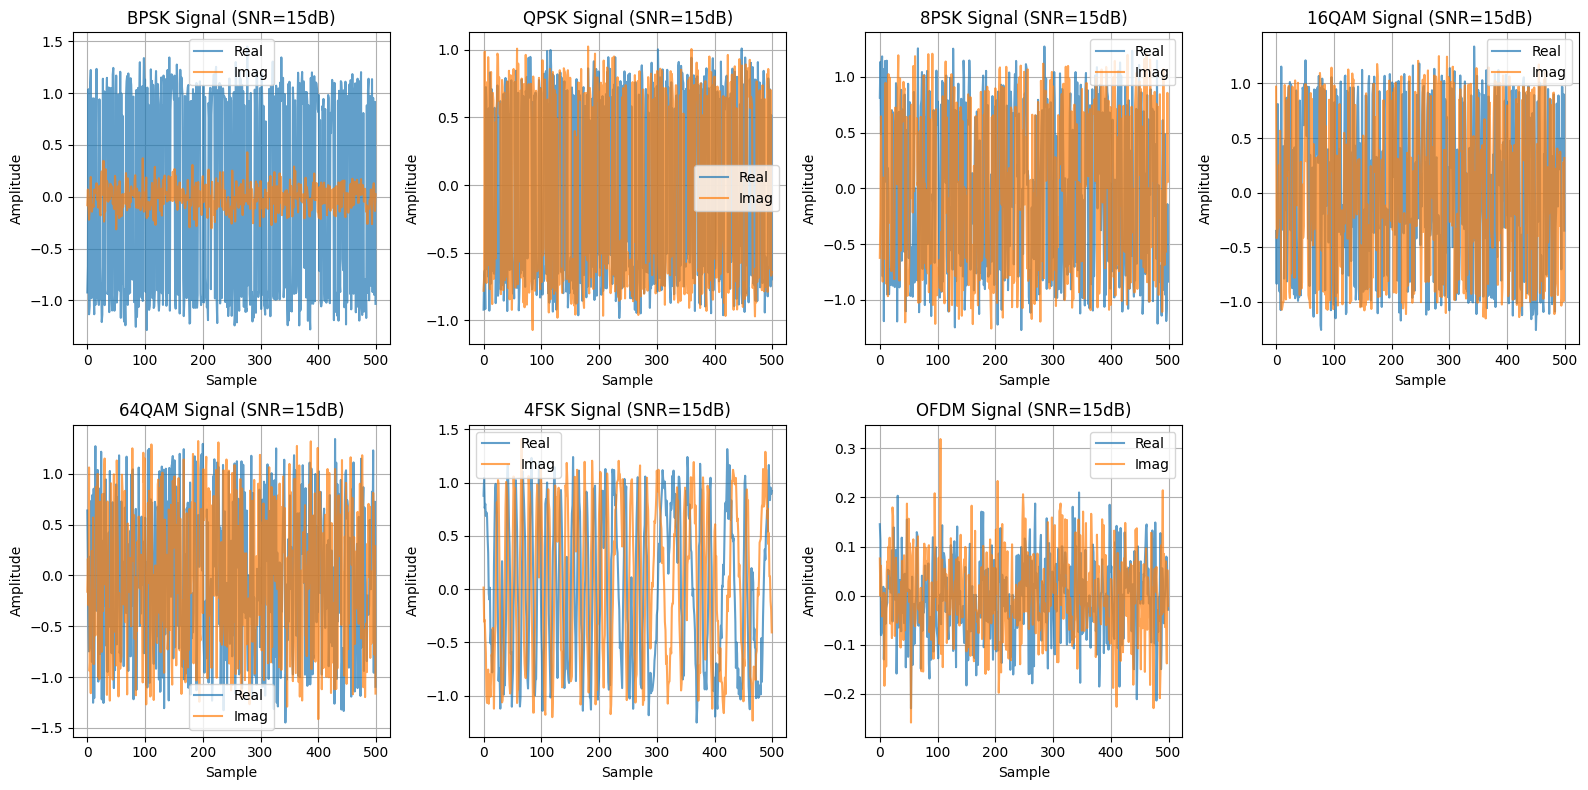

In [3]:
def generate_signal(eng, mod_type, snr_db=10, num_symbols=1000):
    """Generate a modulated signal with AWGN"""
    
    if mod_type == 'BPSK':
        eng.eval(f"data = randi([0 1], {num_symbols}, 1);", nargout=0)
        eng.eval("tx = pskmod(data, 2);", nargout=0)
    
    elif mod_type == 'QPSK':
        eng.eval(f"data = randi([0 3], {num_symbols}, 1);", nargout=0)
        eng.eval("tx = pskmod(data, 4, pi/4);", nargout=0)
    
    elif mod_type == '8PSK':
        eng.eval(f"data = randi([0 7], {num_symbols}, 1);", nargout=0)
        eng.eval("tx = pskmod(data, 8);", nargout=0)
    
    elif mod_type == '16QAM':
        eng.eval(f"data = randi([0 15], {num_symbols}, 1);", nargout=0)
        eng.eval("tx = qammod(data, 16, 'UnitAveragePower', true);", nargout=0)
    
    elif mod_type == '64QAM':
        eng.eval(f"data = randi([0 63], {num_symbols}, 1);", nargout=0)
        eng.eval("tx = qammod(data, 64, 'UnitAveragePower', true);", nargout=0)
    
    elif mod_type == '4FSK':
        eng.eval("M = 4; nsamp = 16; freq_sep = 50; Fs_fsk = 1000;", nargout=0)
        eng.eval(f"data = randi([0 M-1], {num_symbols//16}, 1);", nargout=0)
        eng.eval("tx = fskmod(data, M, freq_sep, nsamp, Fs_fsk);", nargout=0)
    
    elif mod_type == 'OFDM':
        eng.eval("ofdm_mod = comm.OFDMModulator('FFTLength', 64, 'CyclicPrefixLength', 16);", nargout=0)
        eng.eval("ofdm_info = info(ofdm_mod);", nargout=0)
        eng.eval("num_carriers = ofdm_info.DataInputSize(1);", nargout=0)
        eng.eval(f"num_symbols = {num_symbols // 80};", nargout=0)
        eng.eval("tx = [];", nargout=0)
        eng.eval("for k = 1:num_symbols; d = pskmod(randi([0 3], num_carriers, 1), 4, pi/4); tx = [tx; ofdm_mod(d)]; end", nargout=0)
    
    # Add noise
    eng.eval(f"rx = awgn(tx, {snr_db}, 'measured');", nargout=0)
    
    # Get signal from MATLAB
    rx = np.array(eng.workspace['rx']).flatten()
    return rx

# Test signal generation for each modulation type
modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, mod in enumerate(modulations):
    print(f"Generating {mod}...")
    signal = generate_signal(eng, mod, snr_db=15)
    
    # Plot first 500 samples
    axes[idx].plot(np.real(signal[:500]), alpha=0.7, label='Real')
    axes[idx].plot(np.imag(signal[:500]), alpha=0.7, label='Imag')
    axes[idx].set_title(f'{mod} Signal (SNR=15dB)')
    axes[idx].set_xlabel('Sample')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].legend()
    axes[idx].grid(True)

# Hide last subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

Computing CWT for BPSK...
Computing CWT for QPSK...
Computing CWT for 8PSK...
Computing CWT for 16QAM...
Computing CWT for 64QAM...
Computing CWT for 4FSK...
Computing CWT for OFDM...


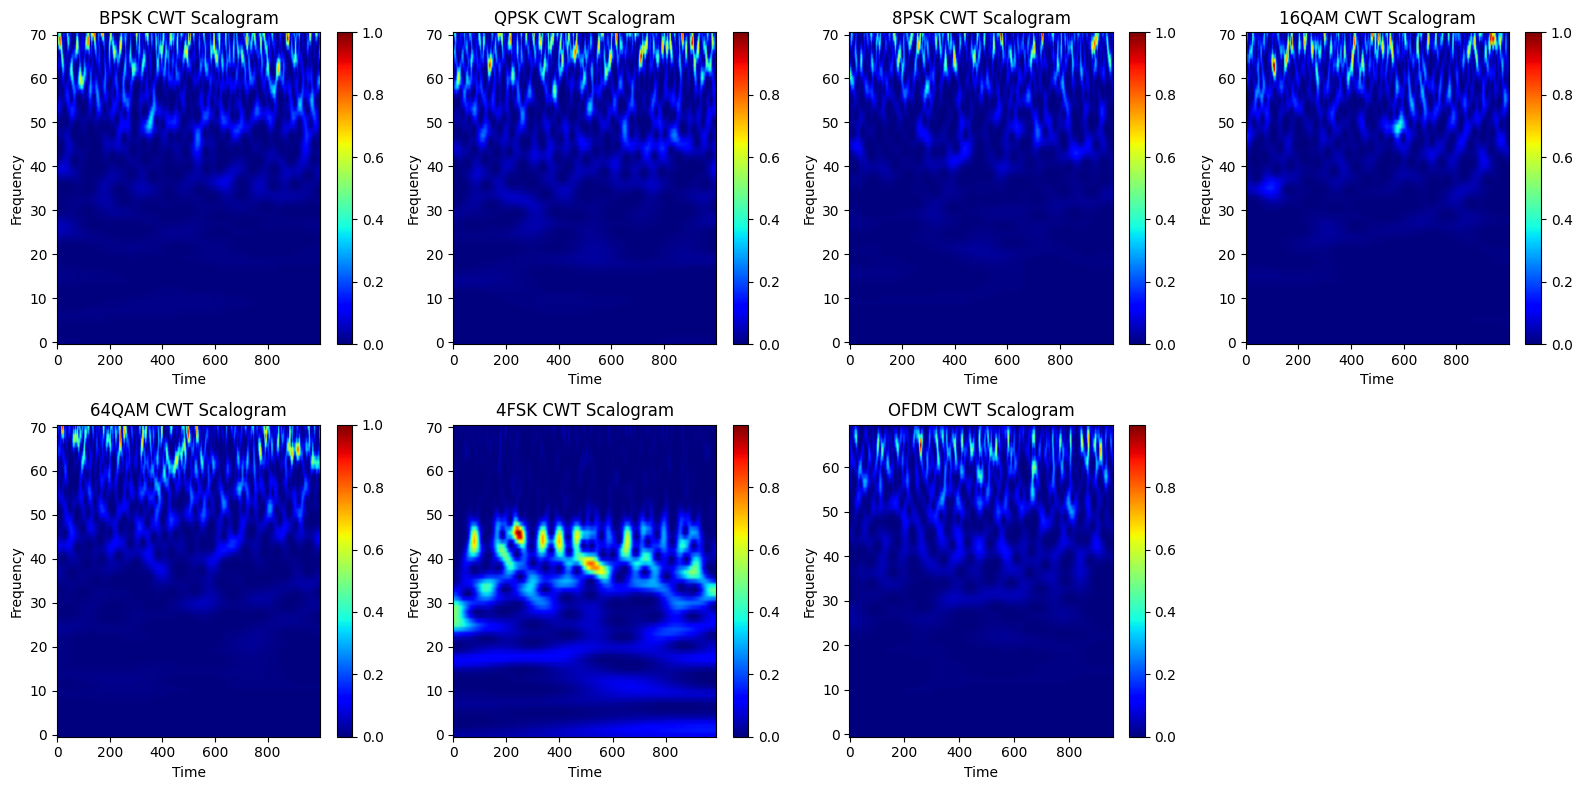


CWT matrix shape: (70, 960)


In [4]:
def compute_cwt(eng, fs=1.0):
    """Compute CWT scalogram from signal in MATLAB workspace"""
    eng.eval(f"[cfs, frq] = cwt(real(rx), {fs});", nargout=0)
    eng.eval("P = abs(cfs).^2;", nargout=0)
    eng.eval("P = flipud(P);", nargout=0)
    eng.eval("P = (P - min(P(:))) / (max(P(:)) - min(P(:)) + 1e-10);", nargout=0)
    
    P = np.array(eng.workspace['P'])
    return P

# Test CWT computation
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, mod in enumerate(modulations):
    print(f"Computing CWT for {mod}...")
    signal = generate_signal(eng, mod, snr_db=15)
    cwt_matrix = compute_cwt(eng)
    
    # Plot CWT
    im = axes[idx].imshow(cwt_matrix, aspect='auto', cmap='jet', origin='lower')
    axes[idx].set_title(f'{mod} CWT Scalogram')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Frequency')
    plt.colorbar(im, ax=axes[idx])

axes[7].axis('off')

plt.tight_layout()
plt.show()

print(f"\nCWT matrix shape: {cwt_matrix.shape}")

Testing QPSK at SNR=-5dB...
Testing QPSK at SNR=0dB...
Testing QPSK at SNR=5dB...
Testing QPSK at SNR=10dB...
Testing QPSK at SNR=15dB...
Testing QPSK at SNR=20dB...


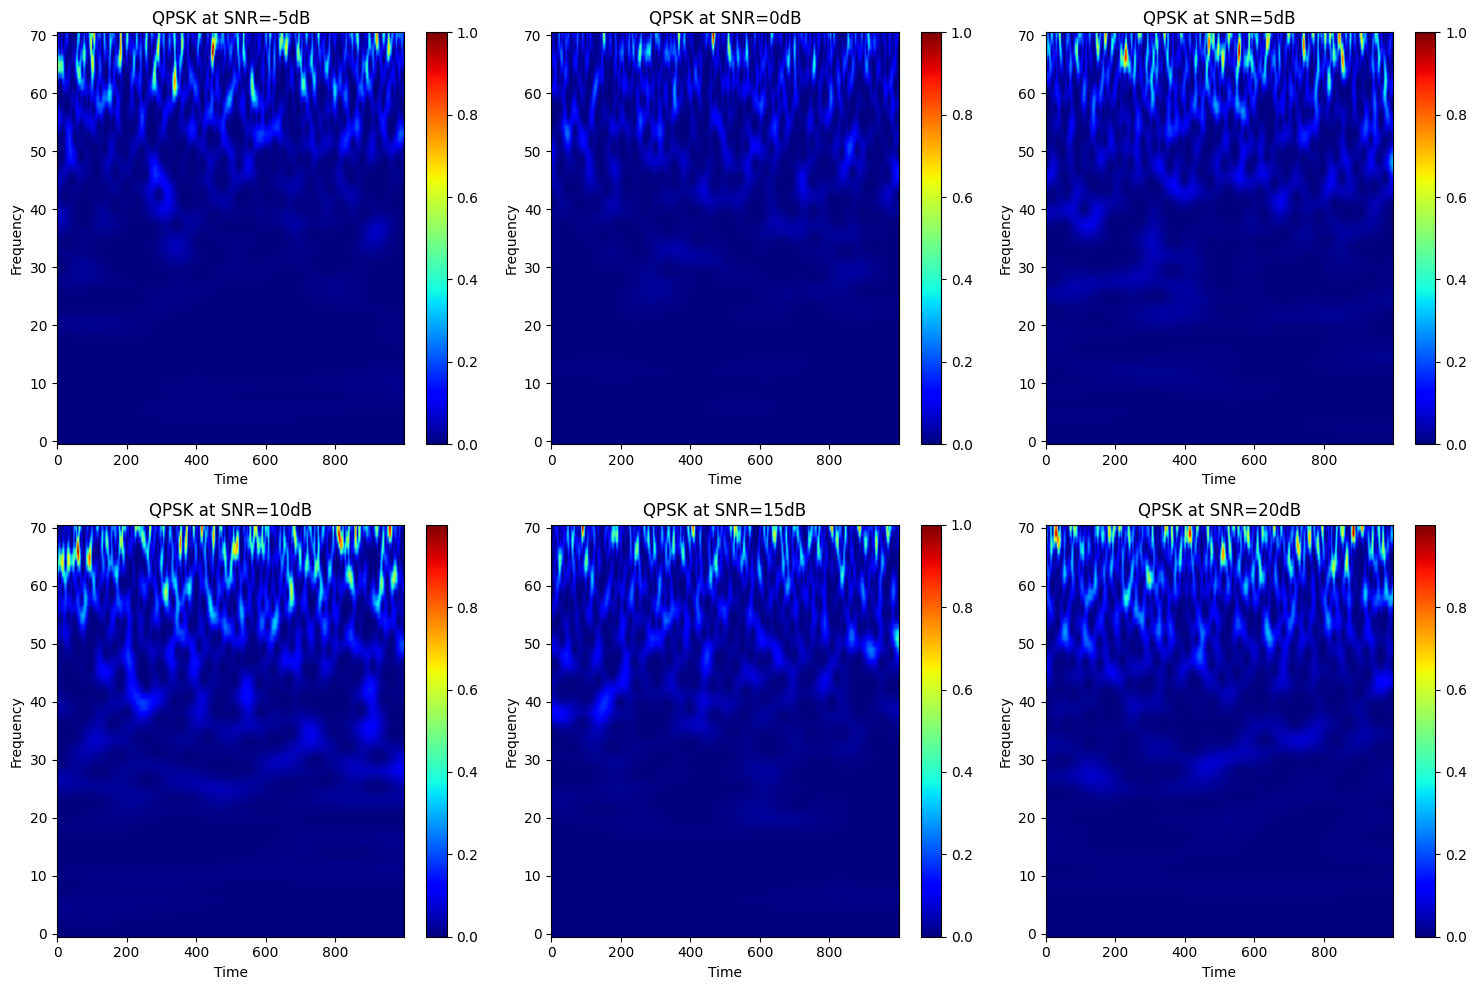

In [5]:
# Test SNR impact on CWT
test_mod = 'QPSK'
snr_values = [-5, 0, 5, 10, 15, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, snr in enumerate(snr_values):
    print(f"Testing {test_mod} at SNR={snr}dB...")
    signal = generate_signal(eng, test_mod, snr_db=snr)
    cwt_matrix = compute_cwt(eng)
    
    im = axes[idx].imshow(cwt_matrix, aspect='auto', cmap='jet', origin='lower')
    axes[idx].set_title(f'{test_mod} at SNR={snr}dB')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Frequency')
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

---
## 2. Data Augmentation Testing

Visualize the effect of different augmentation techniques.

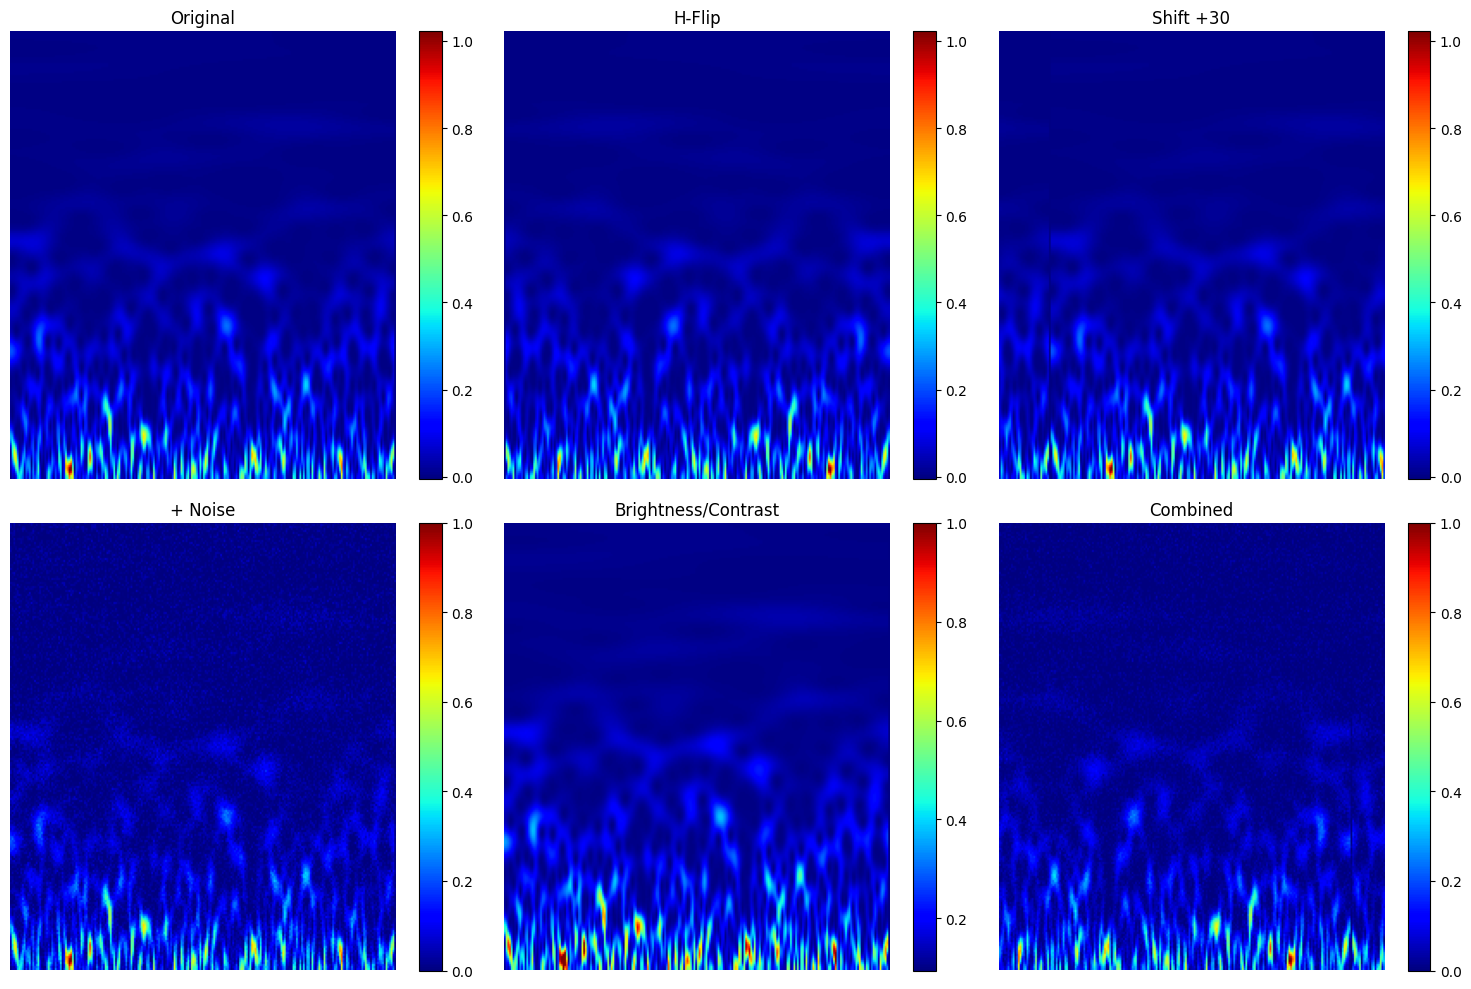

In [6]:
def augment_image(image):
    """Apply various augmentations"""
    augmented = {}
    
    # Original
    augmented['Original'] = image.copy()
    
    # Horizontal flip
    augmented['H-Flip'] = np.fliplr(image).copy()
    
    # Time shift
    shift = 30
    augmented['Shift +30'] = np.roll(image, shift, axis=1)
    
    # Add noise
    noisy = image + np.random.normal(0, 0.02, image.shape)
    augmented['+ Noise'] = np.clip(noisy, 0, 1)
    
    # Brightness/Contrast
    alpha = 1.2  # contrast
    beta = 0.1   # brightness
    augmented['Brightness/Contrast'] = np.clip(alpha * image + beta, 0, 1)
    
    # Combined
    combined = np.fliplr(image).copy()
    combined = np.roll(combined, -20, axis=1)
    combined = combined + np.random.normal(0, 0.015, combined.shape)
    augmented['Combined'] = np.clip(combined, 0, 1)
    
    return augmented

# Generate sample and test augmentations
test_signal = generate_signal(eng, 'QPSK', snr_db=10)
cwt_original = compute_cwt(eng)

# Resize to 224x224 (ResNet input size)
target_size = (224, 224)
cwt_resized = zoom(cwt_original, (
    target_size[0] / cwt_original.shape[0],
    target_size[1] / cwt_original.shape[1]
))

augmented_images = augment_image(cwt_resized)

# Plot all augmentations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, img) in enumerate(augmented_images.items()):
    im = axes[idx].imshow(img, aspect='auto', cmap='jet')
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

---
## 3. Model Architecture Inspection

Explore the ResNet18 architecture and custom classifier head.

In [7]:
def create_model(num_classes=7):
    """Create ResNet18 with custom classifier"""
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)
    )
    
    return model

# Create model
model = create_model(num_classes=7)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
# Test forward pass
dummy_input = torch.randn(1, 3, 224, 224)  # Batch of 1, RGB, 224x224
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (raw logits): {output}")
print(f"\nSoftmax probabilities: {torch.softmax(output, dim=1)}")

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])

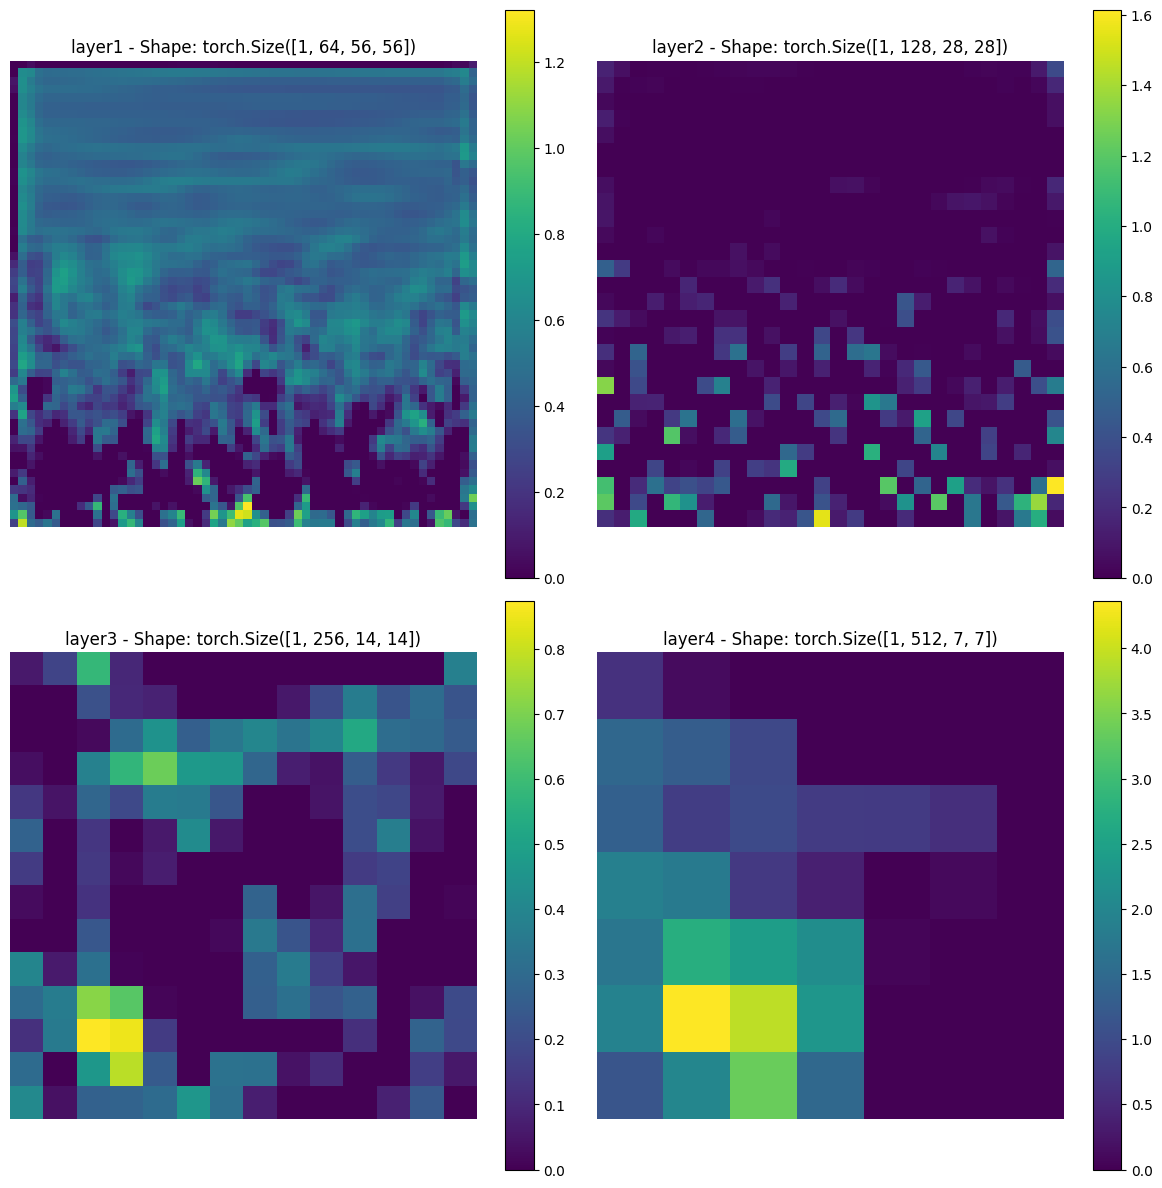

In [9]:
# Visualize feature maps from intermediate layers
from torchvision.models.feature_extraction import create_feature_extractor

# Create feature extractor
return_nodes = {
    'layer1': 'layer1',
    'layer2': 'layer2',
    'layer3': 'layer3',
    'layer4': 'layer4',
}

feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)

# Convert CWT to tensor
cwt_tensor = torch.from_numpy(cwt_resized).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).float()

# Extract features
features = feature_extractor(cwt_tensor)

# Plot feature maps from each layer
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, (layer_name, feat_map) in enumerate(features.items()):
    # Take first channel of feature map
    feat = feat_map[0, 0].detach().numpy()
    
    im = axes[idx].imshow(feat, cmap='viridis')
    axes[idx].set_title(f'{layer_name} - Shape: {feat_map.shape}')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

---
## 4. Training Loop Debug

Test training on a small batch to verify gradients flow correctly.

In [10]:
class ModulationDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].copy()
        label = self.labels[idx]

        if self.augment:
            if np.random.random() > 0.5:
                image = np.fliplr(image).copy()
            shift = np.random.randint(-20, 20)
            image = np.roll(image, shift, axis=1)
            if np.random.random() > 0.5:
                noise = np.random.normal(0, 0.02, image.shape)
                image = image + noise
                image = np.clip(image, 0, 1)

        # Convert to 3-channel RGB
        image = np.stack([image, image, image], axis=0)
        image = torch.tensor(image, dtype=torch.float32)

        return image, label

# Generate small debug dataset (10 samples per class)
print("Generating small debug dataset...")
images_debug = []
labels_debug = []

for label_idx, mod in enumerate(modulations):
    print(f"  {mod}...")
    for _ in range(100):
        snr = np.random.uniform(-5, 20)
        signal = generate_signal(eng, mod, snr_db=snr)
        cwt_matrix = compute_cwt(eng)
        cwt_resized = zoom(cwt_matrix, (224/cwt_matrix.shape[0], 224/cwt_matrix.shape[1]))
        images_debug.append(cwt_resized)
        labels_debug.append(label_idx)

images_debug = np.array(images_debug, dtype=np.float32)
labels_debug = np.array(labels_debug, dtype=np.int64)

print(f"\nDebug dataset shape: {images_debug.shape}")
print(f"Labels: {labels_debug}")

Generating small debug dataset...
  BPSK...
  QPSK...
  8PSK...
  16QAM...
  64QAM...
  4FSK...
  OFDM...

Debug dataset shape: (700, 224, 224)
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 

In [11]:
# Create dataset and dataloader
debug_dataset = ModulationDataset(images_debug, labels_debug, augment=True)
debug_loader = DataLoader(debug_dataset, batch_size=8, shuffle=True)

# Create fresh model
model = create_model(num_classes=7)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Setup optimizer and loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Using device: {device}")
print(f"Dataset size: {len(debug_dataset)}")

Using device: cuda
Dataset size: 700


Training for 20 iterations...

Epoch  1 - Loss: 2.1830, Acc: 0.1250
Epoch  2 - Loss: 2.3464, Acc: 0.0000
Epoch  3 - Loss: 1.6817, Acc: 0.2500
Epoch  4 - Loss: 1.5665, Acc: 0.5000
Epoch  5 - Loss: 1.9209, Acc: 0.5000
Epoch  6 - Loss: 1.7844, Acc: 0.2500
Epoch  7 - Loss: 1.9613, Acc: 0.1250
Epoch  8 - Loss: 1.7256, Acc: 0.3750
Epoch  9 - Loss: 2.2723, Acc: 0.1250
Epoch 10 - Loss: 1.6706, Acc: 0.3750
Epoch 11 - Loss: 1.9078, Acc: 0.1250
Epoch 12 - Loss: 1.7950, Acc: 0.1250
Epoch 13 - Loss: 2.0230, Acc: 0.1250
Epoch 14 - Loss: 1.3339, Acc: 0.5000
Epoch 15 - Loss: 2.2459, Acc: 0.0000
Epoch 16 - Loss: 1.7599, Acc: 0.2500
Epoch 17 - Loss: 2.2929, Acc: 0.1250
Epoch 18 - Loss: 1.5850, Acc: 0.3750
Epoch 19 - Loss: 1.5332, Acc: 0.6250
Epoch 20 - Loss: 1.8698, Acc: 0.2500
Epoch 21 - Loss: 1.8153, Acc: 0.2500
Epoch 22 - Loss: 1.7647, Acc: 0.2500
Epoch 23 - Loss: 1.3704, Acc: 0.5000
Epoch 24 - Loss: 1.4108, Acc: 0.3750
Epoch 25 - Loss: 2.1687, Acc: 0.1250
Epoch 26 - Loss: 2.0179, Acc: 0.1250
Epoch 2

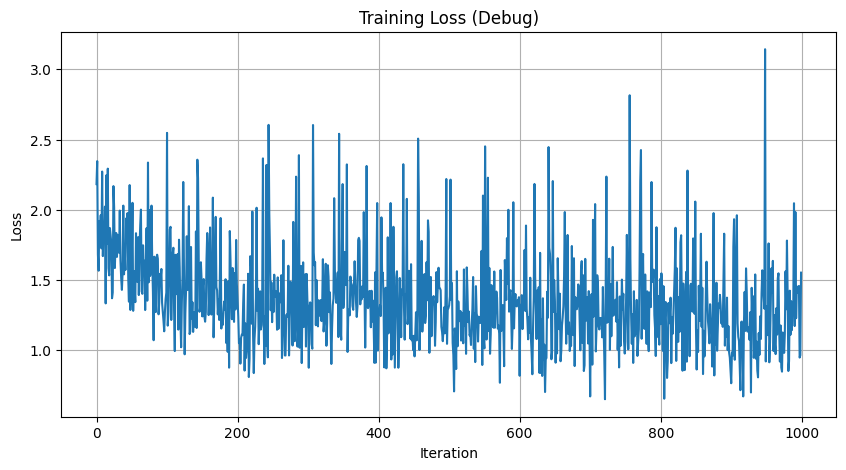


✅ Training loop working! Loss should decrease.


In [12]:
# Train for a few iterations
model.train()
losses = []

print("Training for 20 iterations...\n")
for epoch in range(1000):
    for batch_idx, (inputs, labels) in enumerate(debug_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if batch_idx == 0:  # Only one batch per epoch in debug
            _, preds = torch.max(outputs, 1)
            acc = (preds == labels).float().mean()
            print(f"Epoch {epoch+1:2d} - Loss: {loss.item():.4f}, Acc: {acc.item():.4f}")
            break

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss (Debug)')
plt.grid(True)
plt.show()

print("\n✅ Training loop working! Loss should decrease.")

---
## 5. Inference Testing

Test model predictions on new samples.

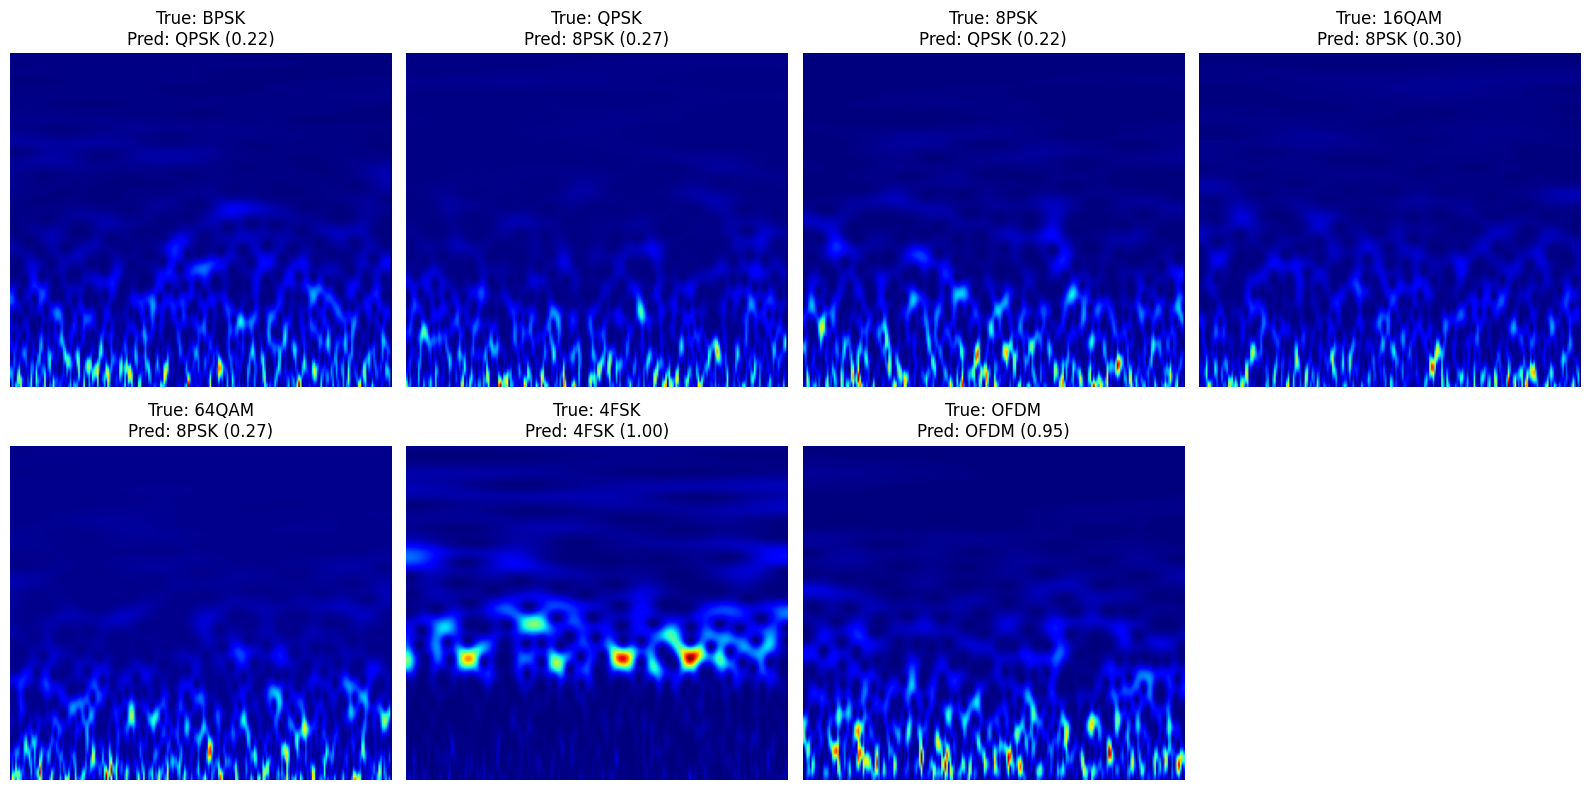

In [13]:
# Generate test samples
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

with torch.no_grad():
    for idx, mod in enumerate(modulations):
        # Generate fresh sample
        signal = generate_signal(eng, mod, snr_db=10)
        cwt_matrix = compute_cwt(eng)
        cwt_resized = zoom(cwt_matrix, (224/cwt_matrix.shape[0], 224/cwt_matrix.shape[1]))
        
        # Convert to tensor
        img_tensor = torch.from_numpy(cwt_resized).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).float()
        img_tensor = img_tensor.to(device)
        
        # Predict
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)
        
        # Plot
        axes[idx].imshow(cwt_resized, aspect='auto', cmap='jet')
        axes[idx].set_title(f'True: {mod}\nPred: {modulations[pred_idx]} ({probs[pred_idx]:.2f})')
        axes[idx].axis('off')

axes[7].axis('off')
plt.tight_layout()
plt.show()

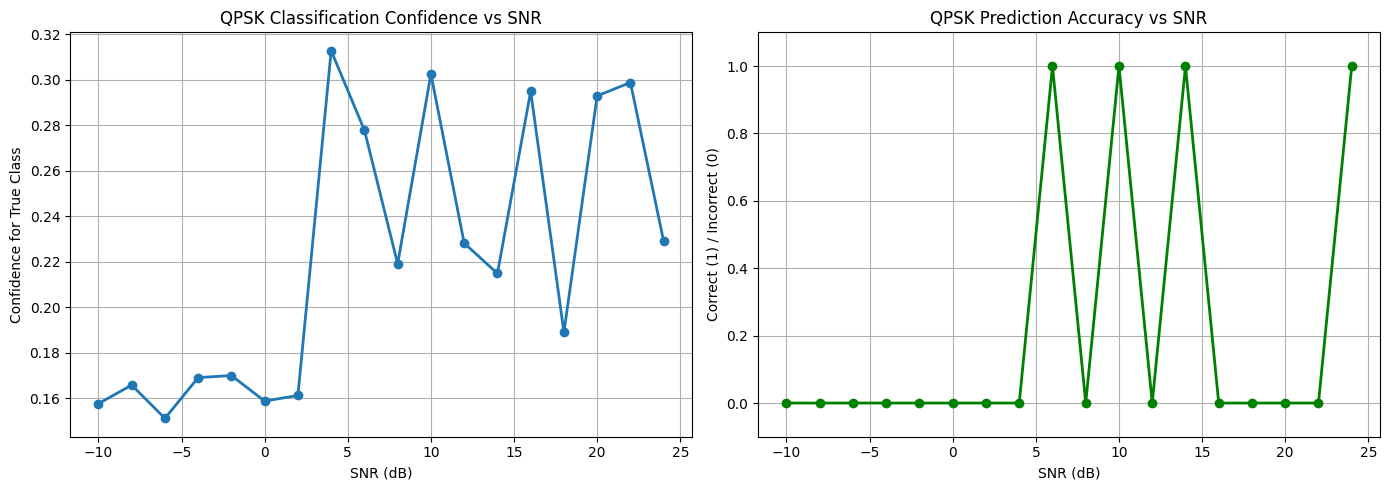

In [14]:
# Test prediction confidence across different SNRs
test_mod = 'QPSK'
test_label = modulations.index(test_mod)
snr_range = range(-10, 25, 2)

confidences = []
correct_predictions = []

model.eval()
with torch.no_grad():
    for snr in snr_range:
        # Generate sample
        signal = generate_signal(eng, test_mod, snr_db=snr)
        cwt_matrix = compute_cwt(eng)
        cwt_resized = zoom(cwt_matrix, (224/cwt_matrix.shape[0], 224/cwt_matrix.shape[1]))
        
        # Predict
        img_tensor = torch.from_numpy(cwt_resized).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).float()
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        
        pred_idx = np.argmax(probs)
        confidences.append(probs[test_label])
        correct_predictions.append(1 if pred_idx == test_label else 0)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(snr_range, confidences, 'o-', linewidth=2)
ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('Confidence for True Class')
ax1.set_title(f'{test_mod} Classification Confidence vs SNR')
ax1.grid(True)

ax2.plot(snr_range, correct_predictions, 'o-', linewidth=2, color='green')
ax2.set_xlabel('SNR (dB)')
ax2.set_ylabel('Correct (1) / Incorrect (0)')
ax2.set_title(f'{test_mod} Prediction Accuracy vs SNR')
ax2.set_ylim([-0.1, 1.1])
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 6. Confusion Matrix Analysis

Analyze which modulations are confused with each other.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate test samples (5 per class)
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for label_idx, mod in enumerate(modulations):
        print(f"Testing {mod}...")
        for _ in range(5):
            snr = np.random.uniform(5, 15)
            signal = generate_signal(eng, mod, snr_db=snr)
            cwt_matrix = compute_cwt(eng)
            cwt_resized = zoom(cwt_matrix, (224/cwt_matrix.shape[0], 224/cwt_matrix.shape[1]))
            
            img_tensor = torch.from_numpy(cwt_resized).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).float()
            img_tensor = img_tensor.to(device)
            output = model(img_tensor)
            _, pred = torch.max(output, 1)
            
            all_preds.append(pred.cpu().item())
            all_labels.append(label_idx)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modulations, yticklabels=modulations)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Debug Model)')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=modulations))

---
## 7. Cleanup

In [ ]:
# Close MATLAB engine when done
eng.quit()
print("MATLAB engine closed.")

---
## Prototyping New Features

Use the cells below to experiment with new ideas!

In [ ]:
# Feature Idea 1: Test different CWT parameters
# TODO: Experiment with different wavelet scales, window sizes, etc.

In [ ]:
# Feature Idea 2: Try different model architectures
# TODO: Test EfficientNet, MobileNet, or custom CNN

In [ ]:
# Feature Idea 3: Implement real-time classification
# TODO: Load model and classify signals from waveform generator